# **Identifying Key Entities in Recipe Data**


**Business Objective**:
The goal of this assignment is to train a Named Entity Recognition (NER) model using Conditional Random Fields (CRF) to extract key entities from recipe data. The model will classify words into predefined categories such as ingredients, quantities and units, enabling the creation of a structured database of recipes and ingredients that can be used to power advanced features in recipe management systems, dietary tracking apps, or e-commerce platforms.

### **Data Description**
The given data is in JSON format, representing a **structured recipe ingredient list** with **Named Entity Recognition (NER) labels**. Below is a breakdown of the data fields:

```json
[
    {
        "input": "6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil",
        "pos": "quantity ingredient ingredient ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient"
    },
    {
      "input": "2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida",
      "pos": "quantity unit ingredient ingredient quantity ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity unit ingredient ingredient"
    }
]


| **Key**  | **Description**  |
|----------|-----------------|
| `input`  | Contains a raw ingredient list from a recipe. |
| `pos`    | Represents the corresponding part-of-speech (POS) tags or NER labels, identifying quantities, ingredients, and units. |


## **1** Import libraries

#### **1.1** Installation of sklearn-crfsuite

sklearn-crfsuite is a Python wrapper for CRFsuite, a fast and efficient implementation of Conditional Random Fields (CRFs). It is designed to integrate seamlessly with scikit-learn for structured prediction tasks such as Named Entity Recognition (NER), Part-of-Speech (POS) tagging, and chunking.

In [1]:
# installation of sklearn_crfsuite
!pip install sklearn_crfsuite==0.5.0


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


#### **1.2** Import necessary libraries

In [2]:
# Import warnings
import warnings

warnings.filterwarnings("ignore")

In [3]:
# Import necessary libraries
import json  # For handling JSON data
import pandas as pd  # For data manipulation and analysis
import re  # For regular expressions (useful for text preprocessing)
import matplotlib.pyplot as plt  # For visualisation
import seaborn as sns  # For advanced data visualisation
import sklearn_crfsuite  # CRF (Conditional Random Fields) implementation for sequence modeling
import numpy as np  # For numerical computations

# Saving and loading machine learning models
import joblib
import random
import spacy
from IPython.display import display, Markdown  # For displaying well-formatted output

from fractions import Fraction  # For handling fractional values in numerical data

# Importing tools for feature engineering and model training
from collections import Counter  # For counting occurrences of elements in a list
from sklearn.model_selection import (
    train_test_split,
)  # For splitting dataset into train and test sets
from sklearn_crfsuite import metrics  # For evaluating CRF models
from sklearn_crfsuite.metrics import flat_classification_report
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
from sklearn.metrics import confusion_matrix

In [4]:
# Ensure pandas displays full content
pd.set_option("display.max_colwidth", None)
pd.set_option("display.expand_frame_repr", False)

## **2** Data Ingestion and Preparation <font color = red>[25 marks]</font> <br>

#### **2.1** *Read Recipe Data from Dataframe and prepare the data for analysis* <font color = red>[12 marks]</font> <br>
Read the data from JSON file, print first five rows and describe the dataframe

##### **2.1.1** **Define a *load_json_dataframe* function** <font color = red>[7 marks]</font> <br>

Define a function that takes path of the ingredient_and_quantity.json file and reads it, convert it into dataframe - df and return it.

In [5]:
# define a function to load json file to a dataframe
def load_json_dataframe(path):
    df = pd.read_json(path)
    return df

##### **2.1.2** **Execute the *load_json_dataframe* function** <font color = red>[2 marks]</font> <br>

In [6]:
# read the json file by giving the file path and create a dataframe
df = load_json_dataframe("./ingredient_and_quantity.json")

##### **2.1.3** **Describe the dataframe** <font color = red>[3 marks]</font> <br>

Print first five rows of dataframe along with dimensions. Display the information of dataframe

In [7]:
# display first five rows of the dataframe - df
df.head()

,input,pos
0,6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil,quantity ingredient ingredient ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient
1,2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida,quantity unit ingredient ingredient quantity ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity unit ingredient ingredient
2,1-1/2 cups Rice Vermicelli Noodles Thin 1 Onion sliced 1/2 cup Carrots Gajjar chopped 1/3 Green peas Matar 2 Chillies 1/4 teaspoon Asafoetida hing Mustard seeds White Urad Dal Split Ghee sprig Curry leaves Salt Lemon juice,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient quantity unit ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient
3,500 grams Chicken 2 Onion chopped 1 Tomato 4 Green Chillies slit inch Ginger finely 6 cloves Garlic 1/2 teaspoon Turmeric powder Haldi Garam masala tablespoon Sesame Gingelly Oil 1/4 Methi Seeds Fenugreek Coriander Dhania Dry Red Fennel seeds Saunf cups Sorrel Leaves Gongura picked and,quantity unit ingredient quantity ingredient ingredient quantity ingredient quantity ingredient ingredient ingredient unit ingredient ingredient quantity unit ingredient quantity unit ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient
4,1 tablespoon chana dal white urad 2 red chillies coriander seeds 3 inches ginger onion tomato Teaspoon mustard asafoetida sprig curry,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient ingredient quantity unit ingredient ingredient ingredient unit ingredient ingredient unit ingredient


In [8]:
# print the dimensions of dataframe - df
df.shape

(285, 2)

In [9]:
# print the information of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   input   285 non-null    object
 1   pos     285 non-null    object
dtypes: object(2)
memory usage: 4.6+ KB


#### **2.2** *Recipe Data Manipulation* <font color = red>[13 marks]</font> <br>
Create derived metrics in dataframe and provide insights of the dataframe

##### **2.2.1** **Create input_tokens and pos_tokens columns by splitting the input and pos from the dataframe** <font color = red>[3 marks]</font> <br>
Split the input and pos into input_tokens and pos_tokens in the dataframe and display it in the dataframe

In [10]:
# split the input and pos into input_tokens and pos_tokens in the dataframe

# Tokenize input
df["input_tokens"] = df["input"].map(lambda x: x.split())
# Tokenize POS
df["pos_tokens"] = df["pos"].map(lambda x: x.split())

In [11]:
# display first five rows of the dataframe - df
df.head()

,input,pos,input_tokens,pos_tokens
0,6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil,quantity ingredient ingredient ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[6, Karela, Bitter, Gourd, Pavakkai, Salt, 1, Onion, 3, tablespoon, Gram, flour, besan, 2, teaspoons, Turmeric, powder, Haldi, Red, Chilli, Cumin, seeds, Jeera, Coriander, Powder, Dhania, Amchur, Dry, Mango, Sunflower, Oil]","[quantity, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, quantity, unit, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]"
1,2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida,quantity unit ingredient ingredient quantity ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity unit ingredient ingredient,"[2-1/2, cups, rice, cooked, 3, tomatoes, teaspoons, BC, Belle, Bhat, powder, 1, teaspoon, chickpea, lentils, 1/2, cumin, seeds, white, urad, dal, mustard, green, chilli, dry, red, 2, cashew, or, peanuts, 1-1/2, tablespoon, oil, asafoetida]","[quantity, unit, ingredient, ingredient, quantity, ingredient, unit, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient]"
2,1-1/2 cups Rice Vermicelli Noodles Thin 1 Onion sliced 1/2 cup Carrots Gajjar chopped 1/3 Green peas Matar 2 Chillies 1/4 teaspoon Asafoetida hing Mustard seeds White Urad Dal Split Ghee sprig Curry leaves Salt Lemon juice,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient quantity unit ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient,"[1-1/2, cups, Rice, Vermicelli, Noodles, Thin, 1, Onion, sliced, 1/2, cup, Carrots, Gajjar, chopped, 1/3, Green, peas, Matar, 2, Chillies, 1/4, teaspoon, Asafoetida, hing, Mustard, seeds, White, Urad, Dal, Split, Ghee, sprig, Curry, leaves, Salt, Lemon, juice]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, quantity, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient]"
3,500 grams Chicken 2 Onion chopped 1 Tomato 4 Green Chillies slit inch Ginger finely 6 cloves Garlic 1/2 teaspoon Turmeric powder Haldi Garam masala tablespoon Sesame Gingelly Oil 1/4 Methi Seeds Fenugreek Coriander Dhania Dry Red Fennel seeds Saunf cups Sorrel Leaves Gongura picked and,quantity unit ingredient quantity ingredient ingredient quantity ingredient quantity ingredient ingredient ingredient unit ingredient ingredient qua

##### **2.2.2** **Provide the length for input_tokens and pos_tokens and validate their length** <font color = red>[2 marks]</font> <br>

Create input_length and pos_length columns in the dataframe and validate both the lengths. Check for the rows that are unequal in input and pos length


In [12]:
# create input_length and pos_length columns for the input_tokens and pos-tokens
df["input_length"] = df["input_tokens"].map(lambda x: len(x))
df["pos_length"] = df["pos_tokens"].map(lambda x: len(x))

In [13]:
# check for the equality of input_length and pos_length in the dataframe
def unequal_lengths(x, y):
    if x != y:
        return True
    else:
        return False


i = 0
list1 = []
for num1, num2 in zip(df["input_length"], df["pos_length"]):
    if unequal_lengths(num1, num2):
        list1.append(i)
    i = i + 1
print(list1)

[17, 27, 79, 164, 207]


##### **2.2.3** **Define a unique_labels function and validate the labels in pos_tokens** <font color = red>[2 marks]</font> <br>

Define a unique_labels function which checks for all the unique pos labels in the recipe & execute it.


In [14]:
# Define a unique_labels function to checks for all the unique pos labels in the recipe & print it
set1 = set()


def unique_labels(x):
    for a in x:
        set1.add(a)


df["pos_tokens"].map(unique_labels)
print(set1)

{'ingredient', 'unit', 'quantity'}


##### **2.2.3** **Provide the insights seen in the recipe data after validation** <font color = red>[1 marks]</font> <br>

Provide the indexes that requires cleaning and formatting in the dataframe

<font color = red>[write your answer]</font> <br>
There are three unique pos tags in the dataset, and the indices which have to be cleaned are [17, 27, 79, 164, 207]

##### **2.2.4** **Drop the rows that have invalid data provided in previous cell** <font color = red> [2 marks]</font> <br>

In [15]:
# drop the irrelevant recipe data
df.drop(list1, inplace=True)

##### **2.2.5** **Update the input_length & pos_length in dataframe**<font color = red> [2 marks]</font> <br>

In [16]:
# update the input and pos length in input_length and pos_length
df

,input,pos,input_tokens,pos_tokens,input_length,pos_length
0,6 Karela Bitter Gourd Pavakkai Salt 1 Onion 3 tablespoon Gram flour besan 2 teaspoons Turmeric powder Haldi Red Chilli Cumin seeds Jeera Coriander Powder Dhania Amchur Dry Mango Sunflower Oil,quantity ingredient ingredient ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient,"[6, Karela, Bitter, Gourd, Pavakkai, Salt, 1, Onion, 3, tablespoon, Gram, flour, besan, 2, teaspoons, Turmeric, powder, Haldi, Red, Chilli, Cumin, seeds, Jeera, Coriander, Powder, Dhania, Amchur, Dry, Mango, Sunflower, Oil]","[quantity, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, quantity, unit, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]",31,31
1,2-1/2 cups rice cooked 3 tomatoes teaspoons BC Belle Bhat powder 1 teaspoon chickpea lentils 1/2 cumin seeds white urad dal mustard green chilli dry red 2 cashew or peanuts 1-1/2 tablespoon oil asafoetida,quantity unit ingredient ingredient quantity ingredient unit ingredient ingredient ingredient ingredient quantity unit ingredient ingredient quantity ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity unit ingredient ingredient,"[2-1/2, cups, rice, cooked, 3, tomatoes, teaspoons, BC, Belle, Bhat, powder, 1, teaspoon, chickpea, lentils, 1/2, cumin, seeds, white, urad, dal, mustard, green, chilli, dry, red, 2, cashew, or, peanuts, 1-1/2, tablespoon, oil, asafoetida]","[quantity, unit, ingredient, ingredient, quantity, ingredient, unit, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient]",34,34
2,1-1/2 cups Rice Vermicelli Noodles Thin 1 Onion sliced 1/2 cup Carrots Gajjar chopped 1/3 Green peas Matar 2 Chillies 1/4 teaspoon Asafoetida hing Mustard seeds White Urad Dal Split Ghee sprig Curry leaves Salt Lemon juice,quantity unit ingredient ingredient ingredient ingredient quantity ingredient ingredient quantity unit ingredient ingredient ingredient quantity ingredient ingredient ingredient quantity ingredient quantity unit ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient ingredient unit ingredient ingredient ingredient ingredient ingredient,"[1-1/2, cups, Rice, Vermicelli, Noodles, Thin, 1, Onion, sliced, 1/2, cup, Carrots, Gajjar, chopped, 1/3, Green, peas, Matar, 2, Chillies, 1/4, teaspoon, Asafoetida, hing, Mustard, seeds, White, Urad, Dal, Split, Ghee, sprig, Curry, leaves, Salt, Lemon, juice]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, quantity, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient]",37,37
3,500 grams Chicken 2 Onion chopped 1 Tomato 4 Green Chillies slit inch Ginger finely 6 cloves Garlic 1/2 teaspoon Turmeric powder Haldi Garam masala tablespoon Sesame Gingelly Oil 1/4 Methi Seeds Fenugreek Coriander Dhania Dry Red Fennel seeds Saunf cups Sorrel Leaves Gongura picked and,quantity unit ingredient quantity ingredient ingredient quantity ingredient quantity ingredient ingredient

##### **2.2.6** **Validate the input_length and pos_length by checking unequal rows** <font color = red> [1 marks]</font> <br>

In [17]:
# validate the input length and pos length as input_length and pos_length
i = 0
list1 = []
for num1, num2 in zip(df["input_length"], df["pos_length"]):
    if unequal_lengths(num1, num2):
        list1.append(i)
    i = i + 1
print(list1)

[]


## **3** Train Validation Split (70 train - 30 val) <font color = red>[6 marks]</font> <br>

#### **3.1** *Perform train and validation split ratio* <font color = red>[6 marks]</font> <br>
Split the dataset with the help of input_tokens and pos_tokens and make a ratio of 70:30 split for training and validation datasets.

###### **3.1.1** **Split the dataset into train_df and val_df into 70:30 ratio** <font color = red> [1 marks]</font> <br>

In [18]:
# split the dataset into training and validation sets
import sklearn
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df[["input_tokens", "pos_tokens"]], train_size=0.7, random_state=42
)

###### **3.1.2** **Print the first five rows of train_df and val_df** <font color = red> [1 marks]</font> <br>

In [19]:
# print the first five rows of train_df
train_df.head()

,input_tokens,pos_tokens
179,"[250, grams, Okra, Oil, 1, Onion, finely, chopped, Tomato, Grated, teaspoon, Ginger, 2, Garlic, Finely, 1/2, Cumin, seeds, 1/4, Teaspoon, asafoetida, cup, cottage, cheese, pinched, coriander, powder, mango, red, chilli, turmeric]","[quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, quantity, ingredient, ingredient, quantity, ingredient, ingredient, quantity, unit, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]"
57,"[200, grams, Paneer, Homemade, Cottage, Cheese, 2, Potato, Aloo, Bay, leaf, tej, patta, Dry, Red, Chilli, 1, tablespoon, Panch, Phoran, Masala, roasted, and, powdered, Tomato, big, sized, teaspoon, Turmeric, powder, Haldi, Cumin, seeds, Jeera, Ginger, grated, Salt, 1/2, Sugar, Sunflower, Oil]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient]"
112,"[500, grams, Cabbage, Patta, Gobi, Muttaikose, 1, teaspoon, Mustard, seeds, 1-1/2, White, Urad, Dal, Split, sprig, Curry, leaves, Green, Chilli, 1/4, cup, Fresh, coconut, Salt]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient]"
218,"[500, grams, Fresh, Figs, 1/4, cup, Lemon, juice, 1, teaspoon, zest, 2, Red, Chilli, flakes, 1/2, Honey, Brown, Sugar, (Demerara, Sugar)]","[quantity, unit, ingredient, ingredient, quantity, unit, ingredient, ingredient, quantity, unit, ingredient, quantity, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient]"
40,"[2, cups, Water, 1, teaspoon, Tea, leaves, 1/4, Milk, 10, Saffron, strands]","[quantity, unit, ingredient, quantity, unit, ingredient, ingredient, quantity, ingredient, quantity, ingredient, ingredient]"


In [20]:
# print the first five rows of the val_df
val_df.head()

,input_tokens,pos_tokens
35,"[1, cup, Ada, 2, liter, Milk, 3/4, Sugar, tablespoon, Ghee, 1/2, teaspoon, Cardamom, Powder, Elaichi]","[quantity, unit, ingredient, quantity, unit, ingredient, quantity, ingredient, unit, ingredient, quantity, unit, ingredient, ingredient, ingredient]"
111,"[1, Carrot, Gajjar, chopped, 7, Potatoes, Aloo, 2, cups, Cauliflower, gobi, cut, to, small, florets, Onion, tablespoon, Ginger, Garlic, Paste, Salt, teaspoons, Sunflower, Oil, 1/2, cup, Fresh, coconut, grated, teaspoon, Whole, Black, Peppercorns, Green, Chillies, Fennel, seeds, Saunf, Poppy, 6, Cashew, nuts, inch, Cinnamon, Stick, Dalchini, Star, anise, 3, Cloves, Laung, Cardamom, Elaichi, Pods/Seeds, Cumin, Jeera]","[quantity, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]"
245,"[1, tablespoon, Sunflower, Oil, 3, Potato, Aloo, Ginger, paste, Green, Chilli, chopped, 1-1/12, tablespoons, Sesame, seeds, Til, teaspoon, Red, powder, Cumin, Jeera, Coriander, Powder, Dhania, 1/2, Garam, masala, 2, Sweet, Chutney, Date, Tamarind, Leaves, few]","[quantity, unit, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]"
264,"[1, cup, green, peas, gram, flour, 1/2, cheese, tsp, ginger, 2, chillies, turmeric, powder, cumin, teaspoon, salt, oil]","[quantity, unit, ingredient, ingredient, ingredient, ingredient, quantity, ingredient, unit, ingredient, quantity, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient]"
157,"[2, cups, Brown, Rice, cooked, tablespoons, Garlic, chopped, 1, Green, Chilli, 1/2, cup, Carrots, (Gajjar), beans, (French, Beans), Bell, Pepper, (Capsicum), Onion, Cabbage, (Patta, Gobi/, Muttaikose), tablespoon, Roasted, tomato, pasta, sauce, -, or, store, bought, Red, teaspoon, Soy, Ginger, freshly, grated, Spring, Greens, Salt, Vinegar, Extra, Virgin, Olive, Oil, as, required]","[quantity, unit, ingredient, ingredient, ingredient, unit, ingredient, ingredient, quantity, ingredient, ingredient, quantity, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, unit, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient, ingredient]"


###### **3.1.3** **Extract the dataset into train_df and val_df into X_train, X_val, y_train and y_val and display their length** <font color = red> [2 marks]</font> <br>

Extract X_train, X_val, y_train and y_val by extracting the list of input_tokens and pos_tokens from train_df and val_df and also display their length

In [21]:
# extract the training and validation sets by taking input_tokens and pos_tokens
X_train = train_df.pop("input_tokens")
X_val = val_df.pop("input_tokens")
y_train = train_df.pop("pos_tokens")
y_val = val_df.pop("pos_tokens")

In [22]:
# validate the shape of training and validation samples
print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)

(196,)
(196,)
(84,)
(84,)


###### **3.1.4** **Display the number of unique labels present in y_train** <font color = red> [2 marks]</font> <br>

In [23]:
# Display the number of unique labels present in y_train
y_train.map(unique_labels)
print(set1)

{'ingredient', 'unit', 'quantity'}


## **4** Exploratory Recipe Data Analysis on Training Dataset <font color = red>[16 marks]</font> <br>

#### **4.1** *Flatten the lists for input_tokens & pos_tokens* <font color = red>[2 marks]</font> <br>

Define a function **flatten_list** for flattening the structure for input_tokens and pos_tokens. The input parameter passed to this function is a nested list.

Initialise the dataset_name with a value ***'Training'***




In [24]:
# flatten the list for nested_list (input_tokens, pos_tokens)
def flatten_list(input_tokens, pos_tokens):
    list1 = []
    list2 = []
    for i in range(0, input_tokens.shape[0]):
        for w in input_tokens.iloc[i]:
            list1.append(w)
    for i in range(0, pos_tokens.shape[0]):
        for w in pos_tokens.iloc[i]:
            list2.append(w)

    return list1, list2

In [25]:
# initialise the dataset_name
dataset_name = "Training"

#### **4.2** *Extract and validate the tokens after using the flattening technique* <font color = red>[2 marks]</font> <br>

Define a function named ***extract_and_validate_tokens*** with parameters dataframe and dataset_name (Training/Validation), validate the length of input_tokens and pos_tokens from dataframe and display first 10 records for both the input_tokens and pos_tokens. Execute this function




In [26]:
# define a extract_and_validate_tokens with parameters (df, dataset_name)
tokens = []
pos_tags = []


def extract_and_validate_tokens(X_train, y_train, dataset_name):

    # call the flatten_list and apply it on input_tokens and pos_tokens
    list1, list2 = flatten_list(X_train, y_train)
    # validate their length and display first 10 records having input and pos tokens
    print(len(list1) == len(list2))
    print(list1[0:10])
    print(list2[0:10])
    return list1, list2

In [27]:
# extract the tokens and its pos tags
tokens, pos_tags = extract_and_validate_tokens(X_train, y_train, dataset_name)

True
['250', 'grams', 'Okra', 'Oil', '1', 'Onion', 'finely', 'chopped', 'Tomato', 'Grated']
['quantity', 'unit', 'ingredient', 'ingredient', 'quantity', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient']


#### **4.3** *Categorise tokens into labels (unit, ingredient, quantity)* <font color = red>[2 marks]</font> <br>

Define a function ***categorize_tokens*** to categorise tokens into ingredients, units and quantities by using extracted tokens in the previous code and return a list of ingredients, units and quantities. Execute this function to get the list.



In [28]:
# define a categorize_tokens function and provide the tokens and pos_tags as parameters and create ingredient, unit and quantity list and return it
# validate the list that it comprised of these labels, if not return empty arrays
ingredient_list = []
unit_list = []
quantity_list = []


def categorize_tokens(list1, list2):
    j = 0
    for i in list2:
        if i == "ingredient":
            ingredient_list.append(list1[j])
        elif i == "unit":
            unit_list.append(list1[j])
        else:
            quantity_list.append(list1[j])
        j = j + 1
    return ingredient_list, unit_list, quantity_list

In [29]:
#  call the function to categorise the labels into respective list
ingredient_list, unit_list, quantity_list = categorize_tokens(tokens, pos_tags)

#### **4.4** *Top 10 Most Frequent Items* <font color = red>[3 marks]</font> <br>

Define a function ***get_top_frequent_items*** to display top 10 most frequent items

Here, item_list is used as a general parameter where you will call this function for ingredient and unit list

Execute this function separately for top 10 most units and ingredients



In [30]:
# define a function get_top_frequent_items to get the top frequent items by using item_list, pos label and dataset_name(Training/Validation) and return top items
top_10_ingredients = []
top_10_units = []


def get_top_frequent_items(item_list, pos_label, dataset_name):

    if dataset_name == "Training":
        if pos_label == "ingredient":
            top_10_ingredients.append(
                sorted(item_list, key=lambda x: item_list.count(x), reverse=True)
            )
            top_10_ingredients1 = []
            for j in top_10_ingredients:
                for i in j:
                    if i not in top_10_ingredients1:
                        top_10_ingredients1.append(i)
            top_10_ingredients1 = top_10_ingredients1[0:10]
            return top_10_ingredients1
        if pos_label == "unit":
            top_10_units1 = []
            top_10_units.append(
                sorted(item_list, key=lambda x: item_list.count(x), reverse=True)
            )
            for j in top_10_units:
                for i in j:
                    if i not in top_10_units1:
                        top_10_units1.append(i)
            top_10_units1 = top_10_units1[0:10]
            return top_10_units1

In [31]:
# get the top ingredients which are frequently seen in the recipe
top_10_ingredients2 = get_top_frequent_items(ingredient_list, "ingredient", "Training")
print(top_10_ingredients2)

['powder', 'Salt', 'seeds', 'Green', 'chopped', 'Oil', 'Red', 'Chilli', 'Coriander', 'Sunflower']


In [32]:
# get the top units which are frequently seen in the recipe
top_10_units2 = get_top_frequent_items(unit_list, "unit", "Training")
print(top_10_units2)
top_10_ingredients = list(np.array(top_10_ingredients).flatten())
top_10_units = list(np.array(top_10_units).flatten())

['teaspoon', 'cup', 'tablespoon', 'grams', 'tablespoons', 'inch', 'cups', 'sprig', 'cloves', 'teaspoons']


#### **4.5** *Plot Top 10 most frequent items* <font color = red>[2 marks]</font> <br>




Define a function ***plot_top_items*** to plot a bar graph on top 10 most frequent items for units and ingredients

Here, item_list is used as a general parameter where you will call this function for ingredient and unit list

In [33]:
# define plot top items with parameters - top_item list, label to suggest whether its ingredient or unit, dataset_name
def plot_top_items(top_item_list, label, dataset_name):
    i = 0
    top_item_set = set()
    for k in top_item_list:
        if k in top_item_set:
            continue
        top_item_set.add(k)
        counts = top_item_list.count(k)
        plt.xlabel(label)
        plt.ylabel(dataset_name)
        plt.bar(k, height=counts)
        i = i + 1
        if i == 10:
            return None

#### **4.6** *Perform EDA analysis* <font color = red>[5 marks]</font> <br>

Plot the bar plots for ingredients and units and provide the insights for training dataset

---



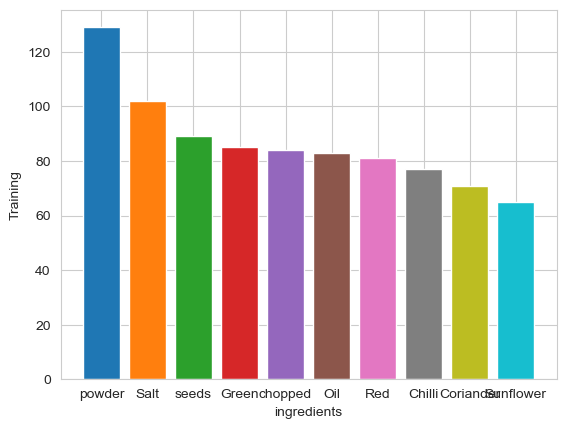

In [34]:
# plot the top frequent ingredients in training data
plot_top_items(top_10_ingredients, "ingredients", "Training")

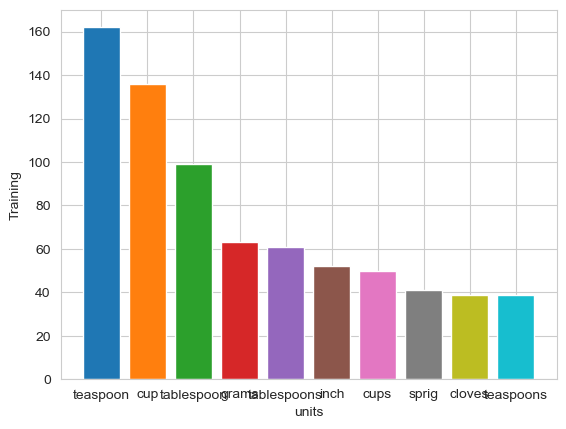

In [35]:
# plot the top frequent units in training data
plot_top_items(top_10_units, "units", "Training")

## **5** Exploratory Recipe Data Analysis on Validation Dataset (Optional)<font color = red> [0 marks]</font> <br>

#### **5.1** *Execute EDA on Validation Dataset with insights (Optional)* <font color = red> [0 marks]</font> <br>
Initialise the dataset_name as ***Validation*** and call the ***plot_top_items*** for top 10 ingredients and units in the recipe data
Provide the insights for the same.



In [36]:
# initialise the dataset_name

In [37]:
# use extract and validate tokens, categorise tokens, get top frequent items for ingredient list and unit list on validation dataframe

In [38]:
# plot the top frequent ingredients in validation data

In [39]:
# plot the top frequent units in training data

## **6** Feature Extraction For CRF Model <font color = red>[30 marks]</font> <br>

### **6.1** *Define a feature functions to take each token from recipe* <font color = red>[10 marks]</font>

Define a function as ***word2features*** which takes a particular recipe and its index to work with all recipe input tokens and include custom key-value pairs.

Also, use feature key-value pairs to mark the beginning and end of the sequence and to also check whether the word belongs to unit, quantity etc. Use keyword sets for unit and quantity for differentiating feature functions well. Also make use of relevant regex patterns on fractions, whole numbers etc.

##### **6.1.1** **Define keywords for unit and quantity and create a quantity pattern to work on fractions, numbers and decimals** <font color = red>[3 marks]</font> <br>

Create sets for **unit_keywords** and ***quantity_keywords*** and include all the words relevant for measuring the ingredients such as cup, tbsp, tsp etc. and in quantity keywords, include words such as half, quarter etc.

Also suggested to use regex pattern as ***quantity_pattern*** to work with quantity in any format such as fractions, numbers and decimals.

Then, load the spacy model and process the entire sentence

In [40]:
# define unit and quantity keywords along with quantity pattern
import re

unit_keywords = set(unit_list)
quantity_keywords = set(quantity_list)
quantity_pattern = re.compile(r"^(\d+\.\d+|\d+/\d+|\d+)$")

In [41]:
# load spaCy model
nlp = spacy.load("en_core_web_sm")

##### **6.1.2** **Define feature functions for CRF** <font color = red>[7 marks]</font> <br>

Define ***word2features*** function and use the parameters such as sentence and its indexing as ***sent*** and ***i*** for extracting token level features for CRF Training.
Build ***features*** dictionary, also mark the beginning and end of the sequence and use the ***unit_keywords***, ***quantity_keywords*** and ***quantity_pattern*** for knowing the presence of quantity or unit in the tokens

While building ***features*** dictionary, include
- ***Core Features*** - The core features of a token should capture its lexical
and grammatical properties. Include attributes like the raw token, its lemma, part-of-speech tag, dependency relation, and shape, as well as indicators for whether it's a stop word, digit, or punctuation. The details of the features are given below:

    - `bias` - Constant feature with a fixed value of 1.0 to aid model learning.
    - `token` - The lowercase form of the current token.
    - `lemma` - The lowercase lemma (base form) of the token.
    - `pos_tag` - Part-of-speech (POS) tag of the token.
    - `tag` - Detailed POS tag of the token.
    - `dep` - Dependency relation of the token in the sentence.
    - `shape` - Shape of the token (e.g., "Xxx" for "Milk").
    - `is_stop` - Boolean indicating if the token is a stopword.
    - `is_digit` - Boolean indicating if the token consists of only digits.
    - `has_digit` - Boolean indicating if the token contains at least one digit.
    - `has_alpha` - Boolean indicating if the token contains at least one alphabetic character.
    - `hyphenated` - Boolean indicating if the token contains a hyphen (-).
    - `slash_present` - Boolean indicating if the token contains a slash (/).
    - `is_title` - Boolean indicating if the token starts with an uppercase letter.
    - `is_upper` - Boolean indicating if the token is fully uppercase.
    - `is_punct` - Boolean indicating if the token is a punctuation mark.

- ***Improved Quantity and Unit Detection*** - Use key-value pairs to mark the presence of quantities and units in the features dictionary. Utilise the unit_keywords, quantity_keywords, and quantity_pattern to identify and flag these elements. The details of the features are given below:

    - `is_quantity` - Boolean indicating if the token matches a quantity pattern or keyword.
    - `is_unit` - Boolean indicating if the token is a known measurement unit.
    - `is_numeric` - Boolean indicating if the token matches a numeric pattern.
    - `is_fraction` - Boolean indicating if the token represents a fraction (e.g., 1/2).
    - `is_decimal` - Boolean indicating if the token represents a decimal number (e.g., 3.14).
    - `preceding_word` - The previous token in the sentence, if available.
    - `following_word` - The next token in the sentence, if available.

- ***Contextual Features*** - Incorporate contextual information by adding features for the preceding and following tokens. Include indicators like BOS and EOS to mark the beginning and end of the sequence, and utilise unit_keywords, quantity_keywords, and quantity_pattern to identify the types of neighboring tokens. The features are given below:

    - `prev_token` - The lowercase form of the previous token.
    - `prev_is_quantity` - Boolean indicating if the previous token is a quantity.
    - `prev_is_digit` - Boolean indicating if the previous token is a digit.
    - `BOS` - Boolean indicating if the token is at the beginning of the sentence.
    - `next_token` - The lowercase form of the next token.
    - `next_is_unit` - Boolean indicating if the next token is a unit.
    - `next_is_ingredient` - Boolean indicating if the next token is not a unit or quantity.
    - `EOS` - Boolean indicating if the token is at the end of the sentence.



In [42]:
# define word2features for processing each token in the sentence sent by using index i.
# use your own feature functions

# Process the entire sentence with spaCy

# --- Core Features ---
length = X_train.shape[0]
import re


def word2features(sent, i):
    prev_word = ""
    following_word = ""
    # print(sent)
    # print(i)
    token = sent[i]

    # Initialize the feature dictionary
    features = {
        # --- Core Features ---
        "bias": 1.0,
        "token": token.text.lower(),
        "lemma": token.lemma_.lower(),
        "pos_tag": token.pos_,
        "tag": token.tag_,
        "dep": token.dep_,
        "shape": token.shape_,
        "is_stop": token.is_stop,
        "is_digit": token.is_digit,
        "has_digit": any(c.isdigit() for c in token.text),
        "has_alpha": any(c.isalpha() for c in token.text),
        "hyphenated": "-" in token.text,
        "slash_present": "/" in token.text,
        "is_title": token.is_title,
        "is_upper": token.is_upper,
        "is_punct": token.is_punct,
    }

    # --- Improved Quantity & Unit Detection ---

    # Check for specific numeric patterns
    features["is_numeric"] = token.like_num
    features["is_fraction"] = bool(re.search(r"^\d+/\d+$", token.text))
    features["is_decimal"] = bool(re.search(r"^\d+\.\d+$", token.text))

    # Check if the token is a known unit
    features["is_unit"] = token.text.lower() in unit_keywords

    # Check if the token is a quantity
    is_quant_keyword = token.text.lower() in quantity_keywords
    is_quant_pattern = bool(quantity_pattern.search(token.text))

    features["is_quantity"] = (
        is_quant_keyword or is_quant_pattern or features["is_numeric"] or token.is_digit
    )

    # Preceding and following word (raw text)
    if i > 0:
        features["preceding_word"] = sent[i - 1].text
    if i < len(sent) - 1:
        features["following_word"] = sent[i + 1].text

    # --- Contextual Features ---

    if i == 0:
        features["BOS"] = True  # Beginning of Sentence
    else:
        # Features for the PREVIOUS token
        prev_token = sent[i - 1]
        features["prev_token"] = prev_token.text.lower()
        features["prev_is_digit"] = prev_token.is_digit

        # Check if previous token was a quantity
        prev_is_quant_keyword = prev_token.text.lower() in quantity_keywords
        prev_is_quant_pattern = bool(quantity_pattern.search(prev_token.text))
        prev_is_numeric_like = prev_token.like_num or prev_token.is_digit
        features["prev_is_quantity"] = (
            prev_is_quant_keyword or prev_is_quant_pattern or prev_is_numeric_like
        )

    if i == len(sent) - 1:
        features["EOS"] = True  # End of Sentence
    else:
        # Features for the NEXT token
        next_token = sent[i + 1]
        features["next_token"] = next_token.text.lower()
        features["next_is_unit"] = next_token.text.lower() in unit_keywords

        # Check if next token is a quantity
        next_is_quant_keyword = next_token.text.lower() in quantity_keywords
        next_is_quant_pattern = bool(quantity_pattern.search(next_token.text))
        next_is_numeric_like = next_token.like_num or next_token.is_digit
        next_is_quantity = (
            next_is_quant_keyword or next_is_quant_pattern or next_is_numeric_like
        )

        # "next_is_ingredient" means it is NOT a unit and NOT a quantity
        features["next_is_ingredient"] = not (
            features["next_is_unit"] or next_is_quantity
        )

    return features

    # --- Improved Quantity & Unit Detection ---

    # --- Contextual Features ---

\### **6.2** *Preparation of Recipe level features* <font color = red>[2 marks]</font>


##### **6.2.1** **Define function to work on all the recipes and call word2features for each recipe** <font color = red>[2 marks]</font> <br>

Define ***sent2features*** function and inputs ***sent*** as a parameter and correctly generate feature functions for each token present in the sentence

In [43]:
# define sent2features by working on each token in the sentence and correctly generate dictionaries for features

from spacy.tokens import Doc  # Import the tool to manually create a "Doc"


def sent2features(sent_tokens):
    """
    Takes your list of tokens and gets spaCy features
    WITHOUT letting spaCy re-tokenize it.
    """

    # 1. Create a 'Doc' object from YOUR list of words.
    #    This forces spaCy to use your tokens (e.g., '1/2')
    #    instead of creating its own (e.g., '1', '/', '2').
    doc = Doc(nlp.vocab, words=sent_tokens)

    # 2. Get all the tools from the nlp pipeline (tagger, parser, etc.)
    #    EXCEPT for the 'tokenizer'.
    pipe_names = [name for name in nlp.pipe_names if name != "tokenizer"]

    # 3. Run all those other tools on the Doc you just made.
    #    This is what adds the .pos_, .lemma_, .dep_ data
    #    that your word2features function needs.
    for pipe_name in pipe_names:
        doc = nlp.get_pipe(pipe_name)(doc)

    # 4. Now, loop through your Doc (which has the correct length)
    #    and extract features.
    return [word2features(doc, i) for i in range(len(doc))]


# def sent2features(sent):
#     i = 0
#     sent1 = ''
#     for s in sent:
#         if i == len(sent) - 1:
#             sent1 = sent1 + s
#         else:
#             sent1 = sent1 + s + ' '
#     sent = nlp(sent1)
#     return [word2features(sent, i) for i in range(len(sent))]

### **6.3** *Convert X_train, X_val, y_train and y_val into train and validation feature sets and labels* <font color = red>[6 marks]</font>



##### **6.3.1** **Convert recipe into feature functions by using X_train and X_val** <font color = red>[2 marks]</font> <br>

Create ***X_train_features*** and ***X_val_features*** as list to include the feature functions for each recipe present in training and validation sets

In [44]:
# Convert input sentences into feature sets by taking training and validation dataset as X_train_features and X_val_features
X_train_features = [sent2features(s) for s in X_train]
print(X_train_features[0])
X_val_features = [sent2features(s) for s in X_val]
print(X_val_features[0])

[{'bias': 1.0, 'token': '250', 'lemma': '250', 'pos_tag': 'NUM', 'tag': 'CD', 'dep': 'nummod', 'shape': 'ddd', 'is_stop': False, 'is_digit': True, 'has_digit': True, 'has_alpha': False, 'hyphenated': False, 'slash_present': False, 'is_title': False, 'is_upper': False, 'is_punct': False, 'is_numeric': True, 'is_fraction': False, 'is_decimal': False, 'is_unit': False, 'is_quantity': True, 'following_word': 'grams', 'BOS': True, 'next_token': 'grams', 'next_is_unit': True, 'next_is_ingredient': False}, {'bias': 1.0, 'token': 'grams', 'lemma': 'gram', 'pos_tag': 'NOUN', 'tag': 'NNS', 'dep': 'nsubj', 'shape': 'xxxx', 'is_stop': False, 'is_digit': False, 'has_digit': False, 'has_alpha': True, 'hyphenated': False, 'slash_present': False, 'is_title': False, 'is_upper': False, 'is_punct': False, 'is_numeric': False, 'is_fraction': False, 'is_decimal': False, 'is_unit': True, 'is_quantity': False, 'preceding_word': '250', 'following_word': 'Okra', 'prev_token': '250', 'prev_is_digit': True, 'pre

##### **6.3.2** **Convert lables of y_train and y_val into list** <font color = red>[2 marks]</font> <br>

Create ***y_train_labels*** and ***y_val_labels*** by using the list of y_train and y_val

In [45]:
# Convert labels into list as y_train_labels and y_val_labels
y_train_labels = list(y_train)
y_val_labels = list(y_val)
print(y_train_labels)
print(y_val_labels)
print(y_train)

[['quantity', 'unit', 'ingredient', 'ingredient', 'quantity', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'unit', 'ingredient', 'quantity', 'ingredient', 'ingredient', 'quantity', 'ingredient', 'ingredient', 'quantity', 'unit', 'ingredient', 'unit', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient'], ['quantity', 'unit', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'quantity', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'quantity', 'unit', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'unit', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'quantity', 'ingredient', 'ingredient', 'ingredient'], ['quantity', 'unit', 'ingredient', 'ingredient'

##### **6.3.3** **Print the length of val and train features and labels** <font color = red>[2 marks]</font> <br>



In [46]:
# print the length of train features and labels
print(len(X_train_features))
print(len(y_train_labels))

196
196


In [47]:
# print the length of validation features and labels
print(len(X_val_features))
print(len(y_val_labels))

84
84


### **6.4** *Applying weights to feature sets* <font color = red>[12 marks]</font> <br>




##### **6.4.1** **Flatten the labels of y_train** <font color = red>[2 marks]</font> <br>

Create ***y_train_flat*** to flatten the structure of nested y_train

In [48]:
# Flatten labels in y_train
y_train_flat = [label for sentence in y_train for label in sentence]

# Print the first 20 labels to verify
print(y_train_flat[:20])

['quantity', 'unit', 'ingredient', 'ingredient', 'quantity', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'unit', 'ingredient', 'quantity', 'ingredient', 'ingredient', 'quantity', 'ingredient', 'ingredient', 'quantity', 'unit']


##### **6.4.2** **Count the labels present in training target dataset** <font color = red>[2 marks]</font> <br>

Create ***label_counts*** to count the frequencies of labels present in y_train_flat and retrieve the total samples by using the values of label_counts as ***total_samples***

In [49]:
# Count label frequencies as label_counts and total_samples as getting the summation of values of label_counts
y_train_flat, x = flatten_list(pd.Series(y_train), pd.Series(y_train_labels))
label_counts = Counter(y_train_flat)
print(label_counts)
total_samples = sum(label_counts.values())
print(total_samples)

Counter({'ingredient': 5323, 'quantity': 980, 'unit': 811})
7114


##### **6.4.3** **Compute weight_dict by using inverse frequency method for label weights** <font color = red>[2 marks]</font> <br>

- Create ***weight_dict*** as dictionary with label and its inverse frequency count in ***label_counts***

- Penalise ingredient label in the dictionary

In [50]:
# Compute class weights (inverse frequency method) by considering total_samples and label_counts
penalty = 2.0
n = len(label_counts)
weight_dict = {}
for k, v in label_counts.items():
    weight_dict[k] = total_samples / (n * v)

In [51]:
# penalise ingredient label
weight_dict["ingredient"] = weight_dict["ingredient"] * penalty

##### **6.4.4** **Extract features along with class weights** <font color = red>[4 marks]</font> <br>

Define a function ***extract_features_with_class_weights*** to work with training and validation datasets and extract features by applying class weights





In [52]:
# Apply weights to feature extraction in extract_features_with_class_weights by using parameters such as X (input tokens), y(labels) and weight_dict (Class weights)


def extract_features_with_class_weights(X, y, weight_dict):
    weighted_feature_list = []

    # Iterate over each sentence's tokens and its labels simultaneously
    for sent_tokens, sent_labels in zip(X, y):
        # 1. Extract the list of feature dicts for this sentence
        # sent_features = sent2features(sent_tokens)

        weighted_sentence = []

        # 2. Combine features, labels, and weights for each token

        # Look up the weight for this token's label
        # Default to 1.0 if a label is somehow not in the dict
        for features, labels in zip(sent_tokens, sent_labels):
            weight = weight_dict.get(labels, 1.0)

            # Append the 3-part tuple
            features["weight"] = str(weight)
            weighted_sentence.append(features)

        # Add the fully processed sentence to our main list
        weighted_feature_list.append(weighted_sentence)

    return weighted_feature_list

##### **6.4.5** **Execute extract_features_with_class_weights on training and validation datasets** <font color = red>[2 marks]</font> <br>

Create ***X_train_weighted_features*** and ***X_val_weighted_features*** for extracting training and validation features along with their weights by calling ***extract_features_with_class_weights*** on the datasets

In [53]:
# Apply manually computed class weights
X_train_weighted_features = extract_features_with_class_weights(
    X_train_features, y_train_labels, weight_dict
)

print(X_train_weighted_features[0])
print(X_train_features[0])
# X_train_weighted_features = [label for sent in X_train_weighted_features for label in sent]
# X_val_weighted_features = [label for sent in X_val_weighted_features for label in sent]
print(X_train_weighted_features[0])
print(len(y_train_flat))
print(len(X_train_weighted_features))

[{'bias': 1.0, 'token': '250', 'lemma': '250', 'pos_tag': 'NUM', 'tag': 'CD', 'dep': 'nummod', 'shape': 'ddd', 'is_stop': False, 'is_digit': True, 'has_digit': True, 'has_alpha': False, 'hyphenated': False, 'slash_present': False, 'is_title': False, 'is_upper': False, 'is_punct': False, 'is_numeric': True, 'is_fraction': False, 'is_decimal': False, 'is_unit': False, 'is_quantity': True, 'following_word': 'grams', 'BOS': True, 'next_token': 'grams', 'next_is_unit': True, 'next_is_ingredient': False, 'weight': '2.419727891156463'}, {'bias': 1.0, 'token': 'grams', 'lemma': 'gram', 'pos_tag': 'NOUN', 'tag': 'NNS', 'dep': 'nsubj', 'shape': 'xxxx', 'is_stop': False, 'is_digit': False, 'has_digit': False, 'has_alpha': True, 'hyphenated': False, 'slash_present': False, 'is_title': False, 'is_upper': False, 'is_punct': False, 'is_numeric': False, 'is_fraction': False, 'is_decimal': False, 'is_unit': True, 'is_quantity': False, 'preceding_word': '250', 'following_word': 'Okra', 'prev_token': '25

## **7** Model Building and Training <font color = red>[10 marks]</font> <br>

### **7.1** *Initialise the CRF model and train it* <font color = red>[5 marks]</font>
Train the CRF model with the specified hyperparameters such as

### CRF Model Hyperparameters Explanation

| Parameter                  | Description |
|----------------------------|-------------|
| **algorithm='lbfgs'**      | Optimisation algorithm used for training. `lbfgs` (Limited-memory Broyden–Fletcher–Goldfarb–Shanno) is a quasi-Newton optimisation method. |
| **c1=0.5**                | L1 regularisation term to control sparsity in feature weights. Helps in feature selection. |
| **c2=1.0**                | L2 regularisation term to prevent overfitting by penalising large weights. |
| **max_iterations=100**     | Maximum number of iterations for model training. Higher values allow more convergence but increase computation time. |
| **all_possible_transitions=True** | Ensures that all possible state transitions are considered in training, making the model more robust. |

Use weight_dict for training CRF



In [54]:
# initialise CRF model with the specified hyperparameters and use weight_dict

import sklearn_crfsuite
from sklearn_crfsuite import metrics

crf = sklearn_crfsuite.CRF(
    verbose=True,
    algorithm="lbfgs",
    c1=0.5,
    c2=1.0,
    max_iterations=100,
    all_possible_transitions=True,
)

# train the CRF model with the weighted training data


# 1. Initialise the CRF model with specified hyperparameters

# 3. Train the CRF model
# We pass the features, labels, and the newly created sample_weight list
print("Starting CRF model training...")
crf.fit(X_train_weighted_features, y_train_labels)
print("Model training complete.")

Starting CRF model training...


loading training data to CRFsuite: 100%|██████████| 196/196 [00:00<00:00, 3196.39it/s]


Feature generation
type: CRF1d
feature.minfreq: 0.000000
feature.possible_states: 0
feature.possible_transitions: 1
0....1....2....3....4....5....6....7....8....9....10
Number of features: 6449
Seconds required: 0.018

L-BFGS optimization
c1: 0.500000
c2: 1.000000
num_memories: 6
max_iterations: 100
epsilon: 0.000010
stop: 10
delta: 0.000010
linesearch: MoreThuente
linesearch.max_iterations: 20

Iter 1   time=0.01  loss=3356.05  active=5778  feature_norm=1.00
Iter 2   time=0.00  loss=2468.54  active=4284  feature_norm=1.15
Iter 3   time=0.00  loss=932.66   active=3351  feature_norm=2.11
Iter 4   time=0.00  loss=633.57   active=2835  feature_norm=2.55
Iter 5   time=0.00  loss=362.55   active=2210  feature_norm=3.34
Iter 6   time=0.00  loss=228.01   active=1485  feature_norm=4.07
Iter 7   time=0.00  loss=154.89   active=1095  feature_norm=4.82
Iter 8   time=0.00  loss=115.52   active=716   feature_norm=5.63
Iter 9   time=0.00  loss=99.84    active=521   feature_norm=6.28
Iter 10  time=0

Iter 32  time=0.01  loss=86.00    active=96    feature_norm=7.01
Iter 33  time=0.01  loss=86.00    active=95    feature_norm=7.01
Iter 34  time=0.00  loss=86.00    active=95    feature_norm=7.01
Iter 35  time=0.01  loss=86.00    active=95    feature_norm=7.01
Iter 36  time=0.00  loss=86.00    active=95    feature_norm=7.01
Iter 37  time=0.00  loss=86.00    active=95    feature_norm=7.01
Iter 38  time=0.00  loss=86.00    active=95    feature_norm=7.01
Iter 39  time=0.00  loss=86.00    active=95    feature_norm=7.01
Iter 40  time=0.00  loss=86.00    active=95    feature_norm=7.01
Iter 41  time=0.00  loss=86.00    active=95    feature_norm=7.01
Iter 42  time=0.00  loss=86.00    active=95    feature_norm=7.01
Iter 43  time=0.00  loss=86.00    active=95    feature_norm=7.01
Iter 44  time=0.00  loss=86.00    active=95    feature_norm=7.01
Iter 45  time=0.01  loss=86.00    active=95    feature_norm=7.01
Iter 46  time=0.00  loss=86.00    active=95    feature_norm=7.01
Iter 47  time=0.00  loss=

### **7.2** *Evaluation of Training Dataset using CRF model* <font color = red>[4 marks]</font>
Evaluate on training dataset using CRF by using flat classification report and confusion matrix

In [55]:
# evaluate on the training dataset
y_pred = crf.predict(X_train_weighted_features)
print(metrics.flat_f1_score(y_train_labels, y_pred, average="weighted"))

1.0


In [56]:
# specify the flat classification report by using training data for evaluation
print(metrics.flat_classification_report(y_train_labels, y_pred))

              precision    recall  f1-score   support

  ingredient       1.00      1.00      1.00      5323
    quantity       1.00      1.00      1.00       980
        unit       1.00      1.00      1.00       811

    accuracy                           1.00      7114
   macro avg       1.00      1.00      1.00      7114
weighted avg       1.00      1.00      1.00      7114



In [57]:
# create a confusion matrix on training datset
# import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

y_true_flat = [label for sent in y_train_labels for label in sent]
y_pred_flat = [label for sent in y_pred for label in sent]

cm = confusion_matrix(y_true_flat, y_pred_flat)
print(cm)

[[5323    0    0]
 [   0  980    0]
 [   0    0  811]]


### **7.3** *Save the CRF model* <font color = red>[1 marks]</font>
Save the CRF model

In [58]:
# dump the model using joblib as crf_model.pkl
joblib.dump(crf, filename="crf_model.pkl")

['crf_model.pkl']

## **8** Prediction and Model Evaluation <font color = red>[3 marks]</font> <br>

### **8.1** *Predict and Evaluate the CRF model on validation set* <font color = red>[3 marks]</font>
Evaluate the metrics for CRF model by using flat classification report and confusion matrix




In [59]:
# predict the crf model on validation dataset
y_val_pred = crf.predict(X_val_features)
metrics.flat_f1_score(y_val_labels, y_val_pred, average="weighted")

0.9562449201545401

In [60]:
# specify flat classification report
print(metrics.flat_classification_report(y_val_labels, y_val_pred))

              precision    recall  f1-score   support

  ingredient       0.99      0.95      0.97      2107
    quantity       0.92      0.99      0.95       411
        unit       0.83      0.93      0.88       358

    accuracy                           0.96      2876
   macro avg       0.91      0.96      0.93      2876
weighted avg       0.96      0.96      0.96      2876



In [61]:
# create a confusion matrix on validation dataset
from sklearn.metrics import confusion_matrix

y_val_true_flat = [sent for labels in y_val_labels for sent in labels]
y_val_pred_flat = [sent for labels in y_val_pred for sent in labels]
cm2 = confusion_matrix(y_val_true_flat, y_val_pred_flat)
print(cm2)

[[2010   33   64]
 [   3  406    2]
 [  22    4  332]]


## **9** Error Analysis on Validation Data <font color = red>[10 marks]</font> <br>
Investigate misclassified samples in validation dataset and provide the insights


### **9.1** *Investigate misclassified samples in validation dataset* <font color = red>[8 marks]</font>



##### **9.1.1** Flatten the labels of validation data and initialise error data <font color = red>[2 marks]</font> <br>



Flatten the true and predicted labels and initialise the error data as ***error_data***

In [62]:
# flatten Labels and Initialise Error Data
print(y_val_true_flat)
print(y_val_pred_flat)
error_data = []

['quantity', 'unit', 'ingredient', 'quantity', 'unit', 'ingredient', 'quantity', 'ingredient', 'unit', 'ingredient', 'quantity', 'unit', 'ingredient', 'ingredient', 'ingredient', 'quantity', 'ingredient', 'ingredient', 'ingredient', 'quantity', 'ingredient', 'ingredient', 'quantity', 'unit', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'unit', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'unit', 'ingredient', 'ingredient', 'quantity', 'unit', 'ingredient', 'ingredient', 'ingredient', 'unit', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'quantity', 'ingredient', 'ingredient', 'unit', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'quantity', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'ingredient', 'quantity', 'unit', 'ingredient', 'ingredient', 'quantity', 'ingredient', 'ingredient

##### **9.1.2** Iterate the validation data and collect Error Information<font color = red> [2 marks]</font> <br>



Iterate through validation data (X_val, y_val_labels, y_pred_val) and compare true vs. predicted labels. Collect error details, including surrounding context, previous/next tokens, and class weights, then store them in error_data

In [63]:
# iterate and collect Error Information
for i, (tokens, true_labels, pred_labels) in enumerate(
    zip(X_val, y_val_labels, y_val_pred)
):
    # 2. Iterate through each token in the sentence
    for j, (token, y_true, y_pred) in enumerate(zip(tokens, true_labels, pred_labels)):
        # 3. Check if the prediction was incorrect
        if y_true != y_pred:
            # --- Collect Error Details ---

            # Get previous token, handling 'Beginning of Sentence' (BOS)
            prev_token = tokens[j - 1] if j > 0 else "BOS"

            # Get next token, handling 'End of Sentence' (EOS)
            next_token = tokens[j + 1] if j < len(tokens) - 1 else "EOS"

            # Get the class weight of the *true* label
            weight = weight_dict.get(y_true, 1.0)

            # 4. Store all information in the error_data list
            error_data.append(
                {
                    "sentence_id": i,
                    "token_id": j,
                    "token": token,
                    "true_label": y_true,
                    "pred_label": y_pred,
                    "class_weight": weight,
                    "prev_token": prev_token,
                    "next_token": next_token,
                }
            )
            # get previous and next tokens with handling for boundary cases

##### **9.1.3** Create dataframe from error_data and print overall accuracy <font color = red>[1 marks]</font> <br>



Change error_data into dataframe and then use it to illustrate the overall accuracy of validation data

In [64]:
# Create DataFrame and Print Overall Accuracy
from sklearn.metrics import accuracy_score

error_data = pd.DataFrame(error_data)
print(error_data)
print("accuracy = ", accuracy_score(y_val_true_flat, y_val_pred_flat))

     sentence_id  token_id   token  true_label pred_label  class_weight prev_token next_token
0              1        11     cut  ingredient       unit      0.890976       gobi         to
1              1        12      to  ingredient   quantity      0.890976        cut      small
2              1        13   small  ingredient       unit      0.890976         to    florets
3              1        49  Cloves  ingredient       unit      0.890976          3      Laung
4              2        34     few  ingredient   quantity      0.890976     Leaves        EOS
..           ...       ...     ...         ...        ...           ...        ...        ...
123           82        36      or  ingredient       unit      0.890976     cheese      cream
124           82        46      to  ingredient   quantity      0.890976      Sugar   sprinkle
125           83         2     raw  ingredient       unit      0.890976        cup     banana
126           83         7    gram  ingredient       unit   

##### **9.1.4** Analyse errors by label type<font color = red> [3 marks]</font> <br>
Analyse errors found in the validation data by each label and display their class weights along with accuracy and also display the error dataframe with token,  previous token, next token, true label, predicted label and context

In [65]:
# Analyse errors found in the validation data by each label
# and display their class weights along with accuracy
# and display the error dataframe with token, previous token, next token, true label, predicted label and context
val_label_counts = Counter(y_val_true_flat)
error_counts = error_data["true_label"].value_counts()
summary_df = pd.DataFrame(
    {
        "Total_in_Validation": pd.Series(val_label_counts),
        "Error_Count": pd.Series(error_counts),
        "Class_Weight": pd.Series(weight_dict),
    }
)
summary_df["Error_Count"] = summary_df["Error_Count"].fillna(0)
summary_df["Accuracy"] = 1 - (
    summary_df["Error_Count"] / summary_df["Total_in_Validation"]
)

print(summary_df)
print(error_data)

            Total_in_Validation  Error_Count  Class_Weight  Accuracy
ingredient                 2107           97      0.890976  0.953963
quantity                    411            5      2.419728  0.987835
unit                        358           26      2.923962  0.927374
     sentence_id  token_id   token  true_label pred_label  class_weight prev_token next_token
0              1        11     cut  ingredient       unit      0.890976       gobi         to
1              1        12      to  ingredient   quantity      0.890976        cut      small
2              1        13   small  ingredient       unit      0.890976         to    florets
3              1        49  Cloves  ingredient       unit      0.890976          3      Laung
4              2        34     few  ingredient   quantity      0.890976     Leaves        EOS
..           ...       ...     ...         ...        ...           ...        ...        ...
123           82        36      or  ingredient       unit      0.8

### **9.2** *Provide insights from the validation dataset* <font color = red>[2 marks]</font>




 <font color = red>[Write your answer]</font>
As can be seen from the above Datframe most of the error is in identifying "unit" label.Generally the model is stable and has a good accuracy of about 96%. The error rate for ingredient label is 6%, while for quantity is 2% and for unit is 7%.

## **10** Conclusion (Optional) <font color = red>[0 marks]</font> <br>

Write your findings and conclusion.